In [1]:
!nvidia-smi

Tue Mar 10 03:23:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

DATA_DIR = "/content/drive/MyDrive/CMPE255:MortgageLendingProject"
RAW_PATH = os.path.join(DATA_DIR, "data_raw", "hmda_2024_ca_snapshot.csv")

print("File exists:", os.path.exists(RAW_PATH))

File exists: True


In [ ]:
# ---- 2) Load only a sample first ----
SAMPLE_ROWS = 200000
df = pd.read_csv(RAW_PATH, nrows=SAMPLE_ROWS, low_memory=False)

print("Loaded rows:", df.shape[0], "cols:", df.shape[1])
print("\n--- Column list ---")
print(df.columns.tolist())

Loaded rows: 200000 cols: 99

--- Column list ---
['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affordable_units', 'income

In [ ]:
# ---- 3) Basic column summary (dtype, missing %, unique count) ----
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "n_unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

print("\n--- Summary (top 30 by missing %) ---")
display(summary.head(30))

# Save summary to Drive
os.makedirs(os.path.join(DATA_DIR, "outputs"), exist_ok=True)
summary_path = os.path.join(DATA_DIR, "outputs", "hmda_profile_column_summary.csv")
summary.to_csv(summary_path)
print("Saved:", summary_path)


--- Summary (top 30 by missing %) ---


,dtype,missing_pct,n_unique
co-applicant_ethnicity-5,float64,100.0000,0
applicant_ethnicity-5,float64,100.0000,0
applicant_ethnicity-4,float64,99.9960,4
co-applicant_ethnicity-4,float64,99.9950,3
co-applicant_race-5,float64,99.9905,9
applicant_race-5,float64,99.9785,11
co-applicant_race-4,float64,99.9520,13
co-applicant_ethnicity-3,float64,99.8990,5
applicant_race-4,float64,99.8990,13
applicant_ethnicity-3,float64,99.7555,5


Saved: /content/drive/MyDrive/CMPE255:MortgageLendingProject/outputs/hmda_profile_column_summary.csv


Column quality check:
We computed data type, % missing, and number of unique
values for each field. Columns with very high missingness (≈95–100%) are not reliable and will be dropped. We drop lei because it’s a lender ID with many unique values; models can “cheat” by learning which lenders approve more instead of learning true risk factors. Core underwriting fields (loan_amount, income, debt_to_income_ratio, loan_to_value_ratio, interest_rate, property_value) have low missingness and will be kept for modeling.

In [ ]:
# STEP 4: Applying the final filters so we work on the exact dataset cohort we want

# Home purchase only
df = df[df["loan_purpose"] == 1]

# Conventional loans only
df = df[df["loan_type"] == 1]

# Keep only clear decisions: originated (approved) and denied
df = df[df["action_taken"].isin([1, 3])]

# Create the target variable for modeling:
# approved = 1 if originated, 0 if denied
df["approved"] = (df["action_taken"] == 1).astype(int)

print("After filtering, rows and columns:", df.shape)
print(df["approved"].value_counts())
print(df["approved"].value_counts(normalize=True))

After filtering, rows and columns: (159730, 100)
approved
1    139149
0     20581
Name: count, dtype: int64
approved
1    0.871151
0    0.128849
Name: proportion, dtype: float64


After filtering to California 2024, conventional home purchase loans, and keeping only originated and denied outcomes, we obtained 159,730 applications with 87.1% approved and 12.9% denied. This class imbalance will require evaluation metrics beyond accuracy (e.g., precision/recall).

In [ ]:
# STEP 5: Check missing values in the main underwriting fields we likely want to model on
important_cols = [c for c in [
    "loan_amount", "income", "debt_to_income_ratio", "loan_to_value_ratio",
    "interest_rate", "property_value", "loan_term", "occupancy_type"
] if c in df.columns]

missing = (df[important_cols].isna().mean() * 100).sort_values(ascending=False)
missing

,0
interest_rate,12.981281
debt_to_income_ratio,7.183372
income,6.018907
loan_to_value_ratio,5.921242
property_value,1.067426
loan_term,0.269204
loan_amount,0.000000
occupancy_type,0.000000


Several underwriting fields have moderate missingness (e.g., interest_rate ~13%, DTI ~7%). To avoid losing many records, we will use a simple imputation strategy (median for numeric fields and “Unknown” for categorical buckets) before modeling.

In [ ]:
#Checking how many columns will we lose if we dropped missing values instead of imputation
cols = ["interest_rate","debt_to_income_ratio","income","loan_to_value_ratio","property_value","loan_term"]
cols = [c for c in cols if c in df.columns]

rows_before = len(df)
rows_after_drop = len(df.dropna(subset=cols))
print("Rows before:", rows_before)
print("Rows after dropping missing:", rows_after_drop)
print("Rows lost:", rows_before - rows_after_drop)

Rows before: 159730
Rows after dropping missing: 125172
Rows lost: 34558


Dropping rows with missing values would remove 34,558 records (~22% of the dataset), which is too large and may bias the sample. Therefore, we will use a simple imputation strategy (median for numeric fields and an “Unknown” category for bucketed fields) to preserve data coverage.

In [ ]:
# STEP 6: Look at the most common values in DTI and LTV fields
# This helps us understand if the column is numeric or category buckets.

if "debt_to_income_ratio" in df.columns:
    print("Top DTI values:")
    print(df["debt_to_income_ratio"].value_counts().head(15))

if "loan_to_value_ratio" in df.columns:
    print("\nTop LTV values:")
    print(df["loan_to_value_ratio"].value_counts().head(15))

Top DTI values:
debt_to_income_ratio
30%-<36%    19977
20%-<30%    15248
49          12923
48           7845
44           7609
42           7363
47           7183
43           6752
41           6535
46           6444
45           6088
>60%         6083
50%-60%      6034
40           5794
<20%         5764
Name: count, dtype: int64

Top LTV values:
loan_to_value_ratio
80           20776
80.00000      9660
95            8119
75            6977
90            4546
70            3773
95.00000      3682
75.00000      3392
90.00000      2542
97            2454
85            2352
100.00000     2350
60            1576
70.00000      1574
85.00000      1479
Name: count, dtype: int64


DTI values appear in mixed formats (both numeric values and categorical ranges like “30%–<36%”), so we will standardize DTI into consistent buckets before modeling. LTV is numeric but contains duplicate representations (e.g., 80 vs 80.00000), so we will convert it to a single numeric format.

##EDA

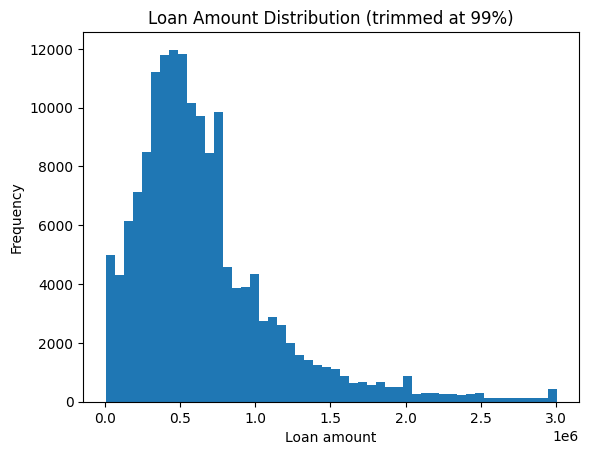

In [ ]:
import matplotlib.pyplot as plt

q99 = df["loan_amount"].quantile(0.99)
df[df["loan_amount"] <= q99]["loan_amount"].plot(kind="hist", bins=50)
plt.title("Loan Amount Distribution (trimmed at 99%)")
plt.xlabel("Loan amount")
plt.show()

The loan amount distribution is right-skewed: most conventional home-purchase loans are concentrated in the mid range, with a smaller number of very large loans forming a long tail. We trimmed the top 1% to visualize typical loan sizes clearly.